In [24]:
print("Hello Jupyter")

Hello Jupyter


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully")

Libraries imported successfully


In [26]:
iris = load_iris()

print("Dataset loaded successfully")

Dataset loaded successfully


In [27]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [28]:
df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [29]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Number of rows: 150
Number of columns: 6

Column names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species', 'species_name'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [30]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [31]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


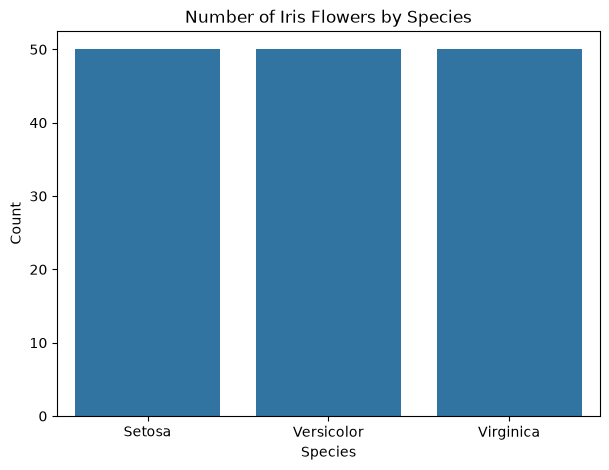

In [32]:
plt.figure(figsize=(7, 5))

sns.countplot(x="species_name", data=df)

plt.title("Number of Iris Flowers by Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

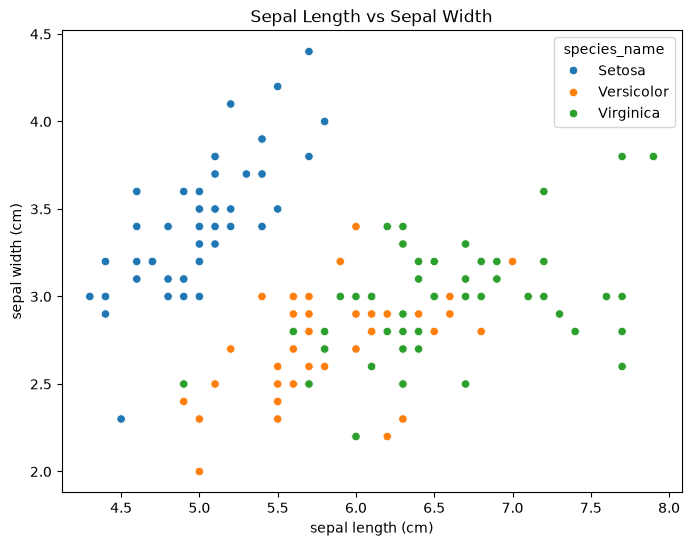

In [33]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species_name"
)

plt.title("Sepal Length vs Sepal Width")
plt.show()

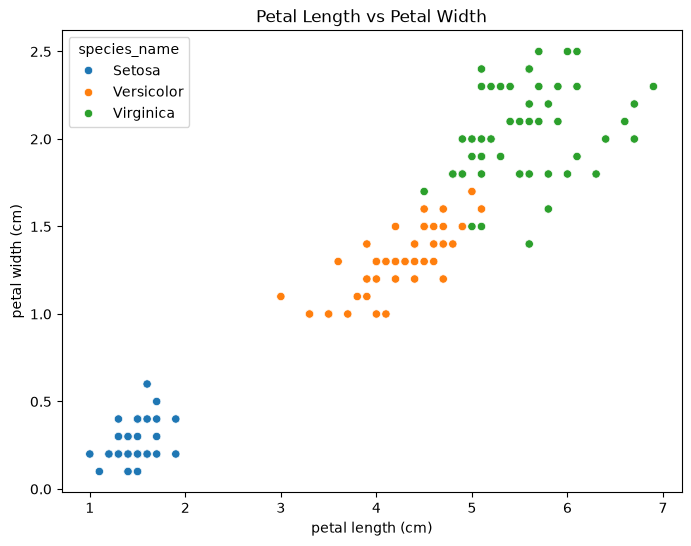

In [34]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species_name"
)

plt.title("Petal Length vs Petal Width")
plt.show()

In [35]:
X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [37]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [38]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]


In [39]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9
Accuracy percentage: 90.0 %


In [40]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [41]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


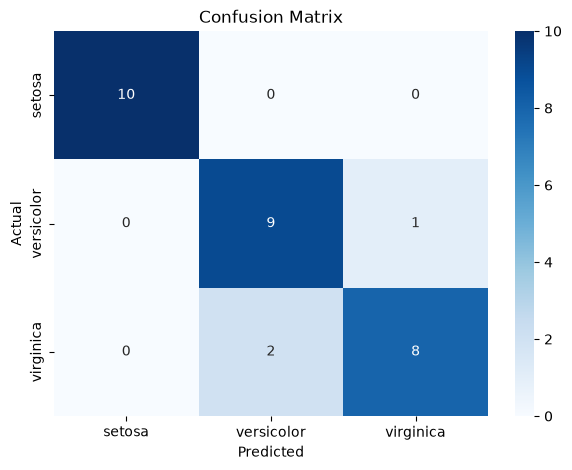

In [42]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted class:", prediction[0])
print("Predicted flower:", iris.target_names[prediction[0]])

Predicted class: 0
Predicted flower: setosa


In [44]:
def predict_flower(sepal_length, sepal_width, petal_length, petal_width):

    flower = [[
        sepal_length,
        sepal_width,
        petal_length,
        petal_width
    ]]

    prediction = model.predict(flower)

    flower_name = iris.target_names[prediction[0]]

    return flower_name

In [45]:
result = predict_flower(5.1, 3.5, 1.4, 0.2)

print("Predicted Flower:", result)

Predicted Flower: setosa


# Iris Flower Classification

## Objective

The objective of this project is to build a machine learning model
that can classify Iris flowers into three species:

- Setosa
- Versicolor
- Virginica

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

## Machine Learning Algorithm

Random Forest Classifier

# Conclusion

In this project, an Iris flower classification model was developed
using the Random Forest Classifier.

The dataset was explored and visualized using Pandas, Matplotlib,
and Seaborn. The dataset was divided into training and testing data,
and the model was trained using the training data.

The trained model was then used to predict Iris flower species.
The model performance was evaluated using accuracy, classification
report, and confusion matrix.

The model can classify Iris flowers into Setosa, Versicolor,
and Virginica based on their sepal and petal measurements.